In [1]:
import numpy as np 
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [39]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# label is telling that what exactly value is stored in 28x28 matrix

In [5]:
import matplotlib.pyplot as plt

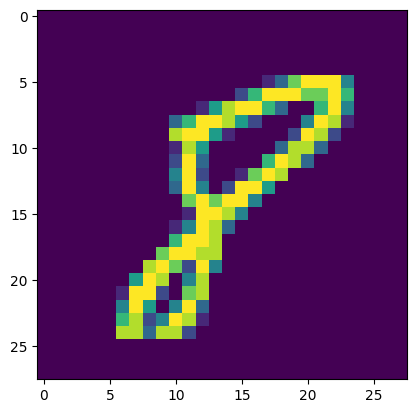

In [6]:
plt.imshow(df.iloc[18306,1:].values.reshape(28,28))

In [40]:
X = df.iloc[:,1:] 
y = df.iloc[:,0]

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
from sklearn.neighbors import KNeighborsClassifier

In [44]:
knn = KNeighborsClassifier()

In [24]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [25]:
# so basically we are calculating the distance of one particular image from rest of the images.

In [26]:
# KNN will take more time in this case

In [27]:
# that's why here we reduce the dimensions so that we don't need to do that much extra computation.

In [28]:
y_pred = knn.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

In [31]:
# mean centring of data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [45]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=100)
# n_components means how much principal component that I want in my final data

In [46]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [47]:
X_train_trf.shape

(33600, 100)

In [48]:
knn = KNeighborsClassifier()

In [50]:
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [51]:
y_pred = knn.predict(X_test_trf)

In [52]:
accuracy_score(y_test,y_pred)

0.9544047619047619

In [53]:
# Predcition we are getting low as compare to normal one because we are removing many features